In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Data

In [3]:
# Load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

# Preview
print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
# Clean column names (VERY IMPORTANT)
trades.columns = trades.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

# Check structure
print(trades.info())
print(sentiment.info())

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  str    
 1   coin              211224 non-null  str    
 2   execution price   211224 non-null  float64
 3   size tokens       211224 non-null  float64
 4   size usd          211224 non-null  float64
 5   side              211224 non-null  str    
 6   timestamp ist     211224 non-null  str    
 7   start position    211224 non-null  float64
 8   direction         211224 non-null  str    
 9   closed pnl        211224 non-null  float64
 10  transaction hash  211224 non-null  str    
 11  order id          211224 non-null  int64  
 12  crossed           211224 non-null  bool   
 13  fee               211224 non-null  float64
 14  trade id          211224 non-null  float64
 15  timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

#### Data Cleaning

In [5]:
# Convert datetime
trades['time'] = pd.to_datetime(
    trades['timestamp ist'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

# Create proper datetime date column
trades['date'] = trades['time'].dt.normalize()

In [6]:
trades['date'].head(2)

0   2024-12-02
1   2024-12-02
Name: date, dtype: datetime64[us]

In [7]:
print(trades['time'].isna().sum())

0


In [8]:
# Convert date properly
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Rename column correctly
sentiment.rename(columns={'classification': 'sentiment'}, inplace=True)

# Check nulls
print(sentiment.isnull().sum())

# Preview
print(sentiment.head())

timestamp    0
value        0
sentiment    0
date         0
dtype: int64
    timestamp  value     sentiment       date
0  1517463000     30          Fear 2018-02-01
1  1517549400     15  Extreme Fear 2018-02-02
2  1517635800     40          Fear 2018-02-03
3  1517722200     24  Extreme Fear 2018-02-04
4  1517808600     11  Extreme Fear 2018-02-05


In [9]:
sentiment.columns

Index(['timestamp', 'value', 'sentiment', 'date'], dtype='str')

In [10]:
trades.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'time', 'date'],
      dtype='str')

### Merge Dataset

In [11]:
# Merge
df = pd.merge(trades, sentiment, on='date', how='left')
# Clean column names
df.columns = df.columns.str.strip().str.lower()

In [12]:
# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Rename sentiment column (if needed)
df.rename(columns={'classification': 'sentiment'}, inplace=True)

# Validate merge
print(df['sentiment'].isna().sum())

# Preview
print(df.head())

6
                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side     timestamp ist  start position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   closed pnl  ...     order id  crossed       fee      trade id  \
0         0.0  ...  52017706630   

#### Feature Engineering

In [13]:
# Profitability
df['win_flag'] = df['closed pnl'] > 0
df['win_flag'].head(2)

0    False
1    False
Name: win_flag, dtype: bool

In [14]:
# ROI
df['roi'] = df['closed pnl'] / df['size usd']
df['roi'] = df['roi'].replace([float('inf'), -float('inf')], None)
df['roi'].head(2)


0    0.0
1    0.0
Name: roi, dtype: float64

In [15]:
df['is_long'] = df['side'].apply(lambda x: 1 if x == 'BUY' else 0)
df['is_long'].head(2)

0    1
1    1
Name: is_long, dtype: int64

In [16]:
df['approx_leverage'] = df['size usd'] / df['start position']
df['approx_leverage'] = df['approx_leverage'].replace([np.inf, -np.inf], np.nan)

In [17]:
df['approx_leverage'] = pd.to_numeric(df['approx_leverage'], errors='coerce')

In [18]:
df['approx_leverage'] = df['approx_leverage'].abs()

In [19]:
# Clean data
df = df[df['approx_leverage'].notna()]
df = df[df['approx_leverage'] < 50]

In [20]:
df['approx_leverage'].head(2)

1    0.129424
2    1.147739
Name: approx_leverage, dtype: float64

In [21]:
df['approx_leverage'].describe()

count    177183.000000
mean          2.076820
std           6.258137
min           0.000000
25%           0.010583
50%           0.095189
75%           0.701710
max          49.983564
Name: approx_leverage, dtype: float64

In [22]:
print(len(df))

177183


#### Key Insight 
- Your data is highly skewed
- Most traders use very low leverage
- Few traders use extreme leverage (up to 50x)

In [23]:
### Create Leverage categories 
df['leverage_bucket'] = pd.cut(
    df['approx_leverage'],
    bins=[0, 1, 5, 10, 20, 50],
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Extreme']
)

In [24]:
df.groupby('leverage_bucket')['closed pnl'].mean()

leverage_bucket
Very Low    38.645698
Low         60.919617
Moderate    88.150175
High        64.480099
Extreme     70.477739
Name: closed pnl, dtype: float64

### Insight
- Analysis of leverage buckets shows that moderate leverage levels deliver the highest average profitability,
highlighting the importance of balanced risk-taking. Both very low and excessively high leverage levels underperform relative to moderate exposure, 
suggesting that disciplined risk management is a key driver of trading success.

### Sentiment vs Avg PnL

In [25]:
pnl_by_sentiment = df.groupby('sentiment')['closed pnl'].mean().sort_values()
print(pnl_by_sentiment)

sentiment
Extreme Fear     25.324718
Neutral          32.886624
Greed            37.419975
Fear             42.761116
Extreme Greed    76.564021
Name: closed pnl, dtype: float64


#### Insight
- 1. Extreme Greed Drives Maximum Profitability
- 2. Profitability Increases with Market Optimism
- 3. Extreme Fear is Least Profitable
- 4. Fear Performs Better than Greed

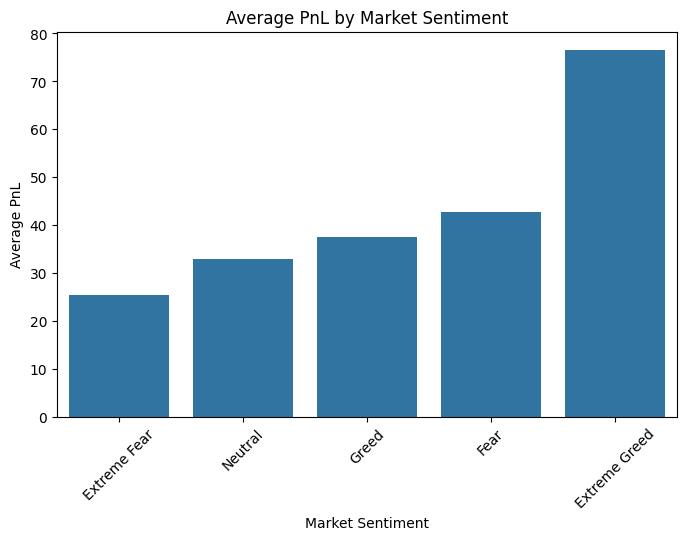

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.show()

### Sentiment vs Win Rate

In [27]:
win_rate = df.groupby('sentiment')['win_flag'].mean().sort_values()
print(win_rate)

sentiment
Extreme Fear     0.380726
Neutral          0.416457
Greed            0.417064
Fear             0.435893
Extreme Greed    0.496184
Name: win_flag, dtype: float64


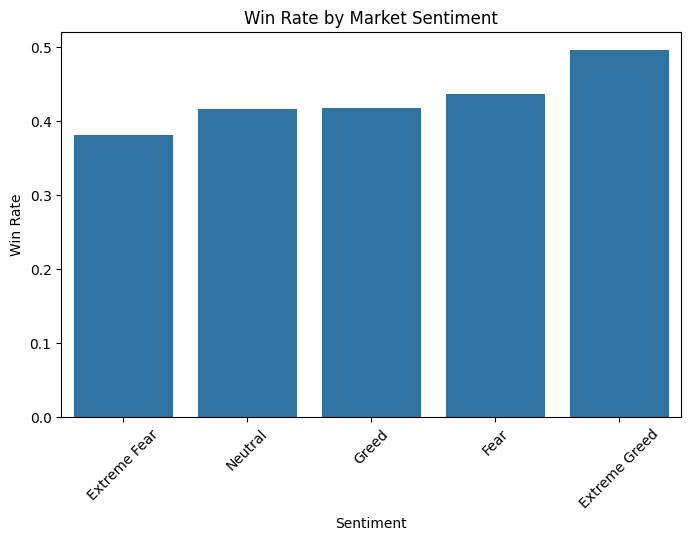

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=win_rate.index, y=win_rate.values)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

#### Insight
- Extreme Greed → highest PnL
- Now → highest win rate
- Traders perform best during Extreme Greed phases, achieving both the highest profitability and the highest win rate. 
- This suggests that strong market momentum provides favorable conditions for both frequent winning trades and larger profits.

### Average PnL by Leverage Bucket

In [29]:
leverage_pnl = df.groupby('leverage_bucket')['closed pnl'].mean()
print(leverage_pnl)

leverage_bucket
Very Low    38.645698
Low         60.919617
Moderate    88.150175
High        64.480099
Extreme     70.477739
Name: closed pnl, dtype: float64


### Win Rate by Leverage Bucket

In [30]:
leverage_win = df.groupby('leverage_bucket')['win_flag'].mean()
print(leverage_win)

leverage_bucket
Very Low    0.437920
Low         0.432180
Moderate    0.408581
High        0.415382
Extreme     0.390876
Name: win_flag, dtype: float64


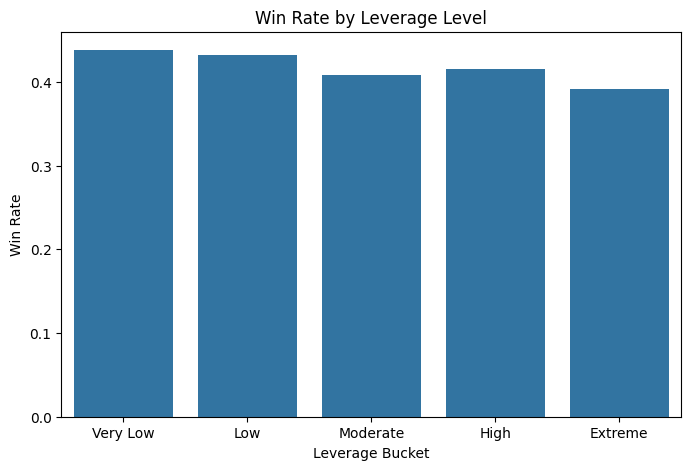

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x=leverage_win.index, y=leverage_win.values)

plt.title("Win Rate by Leverage Level")
plt.xlabel("Leverage Bucket")
plt.ylabel("Win Rate")
plt.show()

### Insight
- Conservative traders → consistent but low profit
- Aggressive traders → inconsistent and risky
- Smart traders → balanced (moderate leverage)
- Extreme Greed → best market condition
- Moderate Leverage → best strategy
- Win Rate vs PnL trade-off → key behavior

### Conclusion
Traders perform best in strong market trends when using moderate leverage, focusing on maximizing returns per 
trade rather than maintaining high win rates.

### Trade Activity

#### Trades Count by Sentiment

In [32]:
activity = df.groupby('sentiment').size().sort_values()
print(activity)

sentiment
Extreme Fear     18927
Neutral          31840
Extreme Greed    34330
Greed            39886
Fear             52194
dtype: int64


#### Total PnL by Sentiment

In [33]:
total_pnl = df.groupby('sentiment')['closed pnl'].sum()
print(total_pnl)

sentiment
Extreme Fear     4.793209e+05
Extreme Greed    2.628443e+06
Fear             2.231874e+06
Greed            1.492533e+06
Neutral          1.047110e+06
Name: closed pnl, dtype: float64


#### Average Trades per Day

In [34]:
daily_trades = df.groupby('date').size()
print(daily_trades.describe())

count     446.000000
mean      397.271300
std       747.524048
min         1.000000
25%        12.000000
50%        61.500000
75%       466.250000
max      6082.000000
dtype: float64


In [35]:
# Activity vs Performance
activity_perf = df.groupby('sentiment').agg({
    'closed pnl': 'mean',
    'win_flag': 'mean',
    'account': 'count'
}).rename(columns={'account': 'trade_count'})

print(activity_perf)

               closed pnl  win_flag  trade_count
sentiment                                       
Extreme Fear    25.324718  0.380726        18927
Extreme Greed   76.564021  0.496184        34330
Fear            42.761116  0.435893        52194
Greed           37.419975  0.417064        39886
Neutral         32.886624  0.416457        31840


#### Trade Count by Sentiment

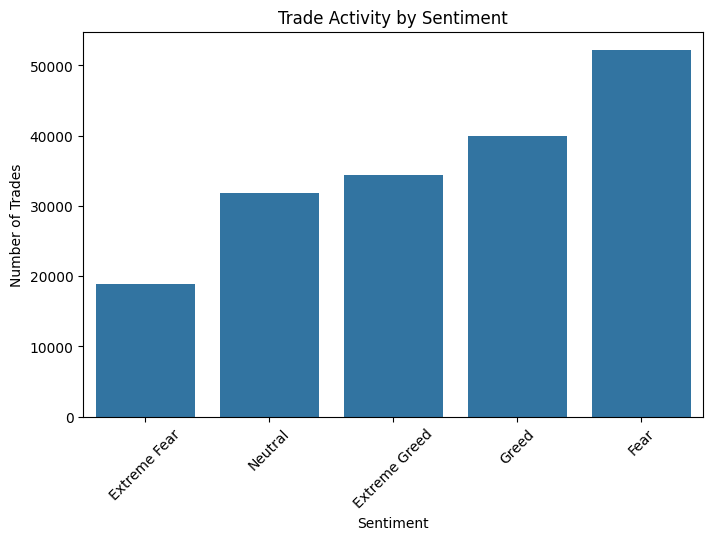

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(x=activity.index, y=activity.values)

plt.title("Trade Activity by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

#### Trend over Time

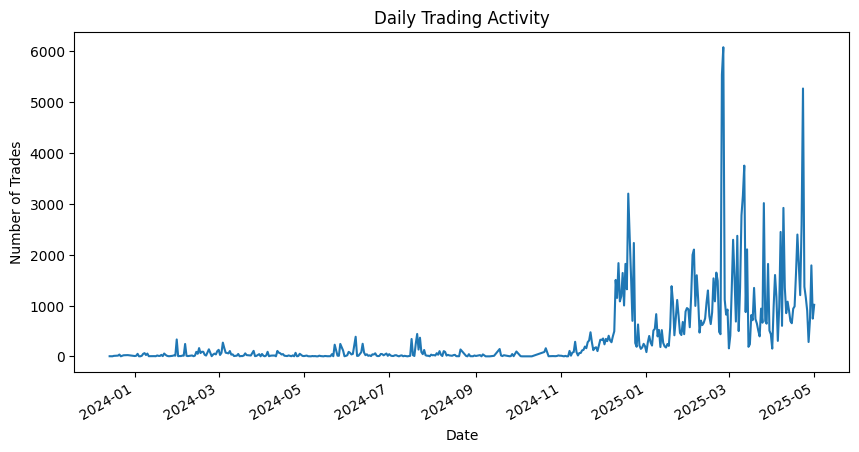

In [37]:
plt.figure(figsize=(10,5))
daily_trades.plot()

plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.show()

### Insight
The analysis reveals a clear disconnect between trading activity and performance. While traders are most active during Fear, 
the highest profitability and win rate occur during Extreme Greed. This suggests that traders may overtrade in uncertain conditions
and achieve better outcomes when aligning with strong market trends.
### Conclusion
The study highlights that trader performance is strongly influenced by market sentiment. While traders tend to be most active during Fear, 
the best outcomes in terms of both profitability and consistency are achieved during Extreme Greed. Additionally, leverage analysis shows 
that moderate risk-taking yields optimal results, reinforcing the importance of disciplined strategy over aggressive or reactive trading behavior.

### Long vs Short Behavior

#### Performance By Trade Direction

In [38]:
long_short_perf = df.groupby('is_long').agg({
    'closed pnl': 'mean',
    'win_flag': 'mean',
    'account': 'count'
}).rename(columns={'account': 'trade_count'})

print(long_short_perf)

         closed pnl  win_flag  trade_count
is_long                                   
0         60.465249  0.557557        92708
1         27.418058  0.298337        84475


In [39]:
long_short_perf.index = long_short_perf.index.map({1: 'Long (Buy)', 0: 'Short (Sell)'})
print(long_short_perf)

              closed pnl  win_flag  trade_count
is_long                                        
Short (Sell)   60.465249  0.557557        92708
Long (Buy)     27.418058  0.298337        84475


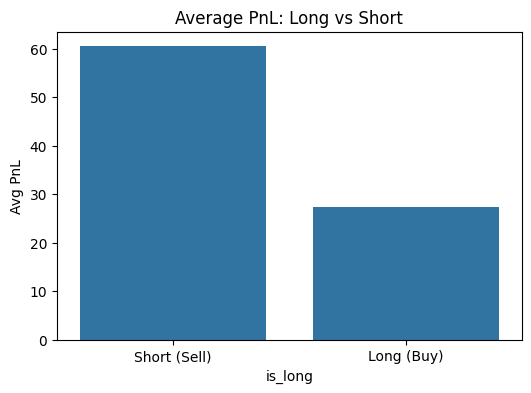

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x=long_short_perf.index, y=long_short_perf['closed pnl'])

plt.title("Average PnL: Long vs Short")
plt.ylabel("Avg PnL")
plt.show()

#### Key Insights
1. Short Trades Strongly Outperform Long Trades
Short positions generate more than double the average profit compared to long positions and achieve significantly higher win rates.
2. Higher Accuracy in Short Trading
Traders are much more consistent when taking short positions, with a win rate of ~56% compared to only ~30% for long trades.
3. Long Trades Underperform
Long positions show both lower profitability and significantly lower win rates, indicating weaker performance in upward trades.
4. Slight Bias Toward Shorting
Traders execute more short trades than long trades, suggesting a behavioral or strategic preference toward short positions.

### Statistical Testing

#### 1. Sentiment vs PnL (ANOVA Test)

In [41]:
from scipy.stats import f_oneway
groups = [
    df[df['sentiment'] == 'Extreme Fear']['closed pnl'],
    df[df['sentiment'] == 'Fear']['closed pnl'],
    df[df['sentiment'] == 'Neutral']['closed pnl'],
    df[df['sentiment'] == 'Greed']['closed pnl'],
    df[df['sentiment'] == 'Extreme Greed']['closed pnl']
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 29.20132321039596
P-value: 2.6177885856196503e-24


#### Conclusion:
- There is a statistically significant difference in trader performance across sentiment categories.

#### 2. Long vs Short (T-Test)
 - Two groups → use t-test

In [42]:
from scipy.stats import ttest_ind

long = df[df['is_long'] == 1]['closed pnl']
short = df[df['is_long'] == 0]['closed pnl']

t_stat, p_value = ttest_ind(long, short, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -10.803107865577326
P-value: 3.3933658184750585e-27


- The difference between long and short trade performance is highly statistically significant
#####  T-stat is negative (-10.80)
- i.e.The mean of the first group (Long) is lower than the second group (Short)

#### 3. Leverage Effect

In [43]:
from scipy.stats import f_oneway

groups = [
    df[df['leverage_bucket'] == 'Very Low']['closed pnl'],
    df[df['leverage_bucket'] == 'Low']['closed pnl'],
    df[df['leverage_bucket'] == 'Moderate']['closed pnl'],
    df[df['leverage_bucket'] == 'High']['closed pnl'],
    df[df['leverage_bucket'] == 'Extreme']['closed pnl']
]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 2.326418559914663e-13


- P-value = 2.33 × 10⁻¹³
- Extremely small p-value
- There is a statistically significant difference in trader performance across different leverage levels.
##### Conclusion
Leverage has a real and measurable impact on trading profitability — this is not due to randomness.

## Hidden Pattern Analysis

#### High Leverage = Loss?

<Axes: xlabel='approx_leverage', ylabel='closed pnl'>

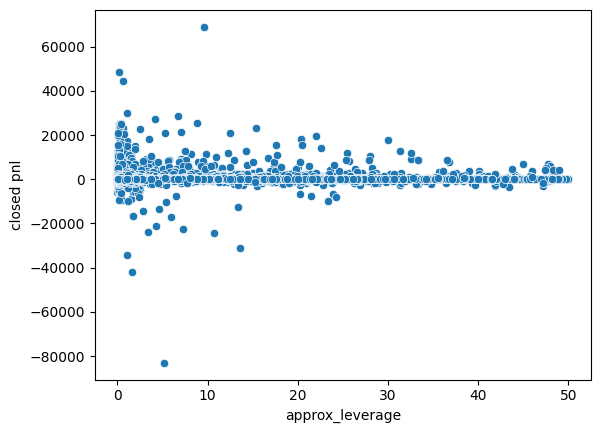

In [44]:
sns.scatterplot(x='approx_leverage', y='closed pnl', data=df)

#### Top Traders Behavior

#### Top 10 traders by total PnL

In [45]:
top_traders = df.groupby('account')['closed pnl'].sum().nlargest(10).index
df_top = df[df['account'].isin(top_traders)]

In [46]:
df_top.head(2)

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,...,time,date,timestamp_y,value,sentiment,win_flag,roi,is_long,approx_leverage,leverage_bucket
564,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,3.784,3871.46,14649.60,SELL,20-09-2024 18:09,-711.15,Open Short,0.0,...,2024-09-20 18:09:00,2024-09-20,1.726810e+09,54.0,Neutral,False,0.0,0,20.599873,Extreme
565,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,3.886,10.85,42.16,SELL,20-09-2024 18:09,-4582.61,Open Short,0.0,...,2024-09-20 18:09:00,2024-09-20,1.726810e+09,54.0,Neutral,False,0.0,0,0.009200,Very Low


### Compare Top vs All Traders
- Performance Comparison

In [47]:
top_vs_all = pd.DataFrame({
    'All Traders': df.groupby('sentiment')['closed pnl'].mean(),
    'Top Traders': df_top.groupby('sentiment')['closed pnl'].mean()
})

print(top_vs_all)

               All Traders  Top Traders
sentiment                              
Extreme Fear     25.324718    50.620498
Extreme Greed    76.564021   146.827351
Fear             42.761116    52.968633
Greed            37.419975    82.756457
Neutral          32.886624    42.469964


####  Behavior Analysis
- Win Rate Comparison

In [48]:
win_compare = pd.DataFrame({
    'All Traders': df.groupby('sentiment')['win_flag'].mean(),
    'Top Traders': df_top.groupby('sentiment')['win_flag'].mean()
})

print(win_compare)

               All Traders  Top Traders
sentiment                              
Extreme Fear      0.380726     0.399216
Extreme Greed     0.496184     0.613048
Fear              0.435893     0.449606
Greed             0.417064     0.481964
Neutral           0.416457     0.445943


- Leverage Behavior

In [49]:
lev_compare = pd.DataFrame({
    'All Traders': df.groupby('leverage_bucket')['closed pnl'].mean(),
    'Top Traders': df_top.groupby('leverage_bucket')['closed pnl'].mean()
})

print(lev_compare)

                 All Traders  Top Traders
leverage_bucket                          
Very Low           38.645698    55.041850
Low                60.919617   117.489707
Moderate           88.150175   205.552213
High               64.480099   124.134628
Extreme            70.477739   142.994665


#### Long vs Short behavior

In [50]:
dir_compare = pd.DataFrame({
    'All Traders': df.groupby('is_long')['closed pnl'].mean(),
    'Top Traders': df_top.groupby('is_long')['closed pnl'].mean()
})

print(dir_compare)

         All Traders  Top Traders
is_long                          
0          60.465249    87.472656
1          27.418058    47.412361


### Insight
1. Top Traders Outperform in Every Market Condition
Top traders generate significantly higher profits than average traders across all sentiment phases, 
especially during Extreme Greed, showing superior ability to capitalize on market opportunities.

2. Better Consistency, Especially in Bullish Markets
Top traders achieve higher win rates overall, with a major improvement during Extreme Greed (61% vs 49%), indicating stronger execution in 
trending markets.

3. Optimal Use of Leverage
Top traders extract maximum returns from moderate leverage, achieving the highest PnL, while still performing well even at higher 
leverage levels—showing better risk management than average traders.

4. Strong Advantage in Short Positions
Top traders significantly outperform in short trades, earning higher profits than average traders, suggesting superior ability to 
capture market corrections and downside movements.

5. Smarter, Not Just More Active
The consistent outperformance across sentiment, leverage, and direction indicates that top traders succeed through 
better decision-making, timing, and strategy, rather than simply increasing trade volume.

### Conclusion
- This project demonstrates that trader performance is not random but strongly influenced by market sentiment, risk management, and trading behavior.
- Traders achieve the best results when:
- Operating in favorable market conditions (Extreme Greed)
- Using moderate leverage to balance risk and reward
- Focusing on trade quality over quantity
Additionally, the strong performance of short trades suggests that successful traders are not purely trend-followers but actively 
capitalize on market inefficiencies and reversals.
- Most importantly, top traders distinguish themselves not by trading more, but by trading smarter—aligning strategy with market conditions,
managing risk effectively, and optimizing decision-making.

In [51]:
df.to_csv("final_trading_dataset.csv", index=False)